In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array



In [2]:
DATA_PATH = './Dataset/'
images = []
IMAGE_SIZE = 32

In [3]:
for img in os.listdir(DATA_PATH):
    img_path = os.path.join(DATA_PATH, img)
    image = load_img(img_path, target_size =(IMAGE_SIZE, IMAGE_SIZE))
    image = img_to_array(image)
    image = image / 255.0
    images.append(image)


images = np.asarray(images)
images = np.reshape(images, (images.shape[0], IMAGE_SIZE * IMAGE_SIZE * 3))
#(100, 3072)

In [4]:
train_dataset, test_dataset = train_test_split(images, test_size = 0.3, random_state = 42)

In [12]:
class RMB():
    def __init__(self, input_size, output_size, learning_rate = 0.1, batch_size = 128):
        self.input_size = input_size
        self.output_size= output_size
        self.learning_rate = learning_rate
        self.batch_size = batch_size

        #RMB cuma ada 2 layer
        #Visible layer = data image masuk/keluar
        #Hidden layer = mencari istribusi probabilitas dari data visible layer

        #perceptron = x1w1 + x2w2 + x3w3 + ... + xnwn + bias

        self.w = tf.zeros([input_size, output_size], np.float32)
        self.vb = tf.zeros([input_size], np.float32)
        self.hb = tf.zeros([output_size], np.float32)


    #(10, 30) . (30, 100) = (10, 100)
    def probability_h_given_v(self, visible, w, hb):
        return tf.nn.sigmoid(tf.matmul(visible, w) + hb)

    #(10, 100) . (100, 30) = (10, 30)
    def probability_v_given_h(self, hidden, w, vb):
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(w)) + vb)

    
    #result =  (layer = random) 
    #sign(result) = 1/-1
    #relu = 1 tetep 1, -1 jadi 0

    def layer_sampling(self, layer):
        return tf.nn.relu(tf.sign(layer - tf.random.uniform(tf.shape(layer))))

    def update_weight_and_bias(self, batch, positive, negative, h0, h1, v1):
        self.w = self.w + self.learning_rate * (positive - negative) / tf.dtypes.cast(tf.shape(batch)[0], tf.float32)
        self.vb = self.vb + self.learning_rate * tf.reduce_mean(batch - v1, 0)
        self.hb = self.hb + self.learning_rate * tf.reduce_mean(h0 - h1, 0)
    
    def train(self, train, epochs  = 100):
        losses = []

        dataset = tf.data.Dataset.from_tensor_slices(train)
        dataset = dataset.batch(self.batch_size)

        for epoch in range(epochs):
            for batch in dataset:
                h0 = self.layer_sampling(self.probability_h_given_v(batch, self.w, self.hb))
                v1 = self.layer_sampling(self.probability_v_given_h(h0, self.w, self.vb))
                h1 = self.probability_h_given_v(v1, self.w, self.hb)

                positive_gradient = tf.matmul(tf.transpose(batch), h0)
                negative_gradient = tf.matmul(tf.transpose(v1), h1)

                self.update_weight_and_bias(
                    batch, 
                    positive_gradient, 
                    negative_gradient,
                    h0, 
                    h1, 
                    v1
                    )
            loss = tf.reduce_mean(tf.square(batch-v1))

            print(f"epochs: {epoch}, reconstruction loss: {loss}")
            losses.append(loss)

        return losses

    def reconstruction(self, test):
        h0 = self.probability_h_given_v(test, self.w, self.hb)
        v1 = self.probability_v_given_h(h0, self.w, self.vb)
        return v1
            




In [13]:
INPUT_SIZE = train_dataset.shape[1]


In [14]:
model = RMB(INPUT_SIZE, 1000)
losses = model.train(train_dataset)

epochs: 0, reconstruction loss: 0.2011350691318512
epochs: 1, reconstruction loss: 0.19873151183128357
epochs: 2, reconstruction loss: 0.2000330537557602
epochs: 3, reconstruction loss: 0.19984175264835358
epochs: 4, reconstruction loss: 0.20224112272262573
epochs: 5, reconstruction loss: 0.20209339261054993
epochs: 6, reconstruction loss: 0.19768254458904266
epochs: 7, reconstruction loss: 0.20101433992385864
epochs: 8, reconstruction loss: 0.1993413269519806
epochs: 9, reconstruction loss: 0.20358294248580933
epochs: 10, reconstruction loss: 0.20202518999576569
epochs: 11, reconstruction loss: 0.1993294656276703
epochs: 12, reconstruction loss: 0.2042766809463501
epochs: 13, reconstruction loss: 0.20271305739879608
epochs: 14, reconstruction loss: 0.20332874357700348
epochs: 15, reconstruction loss: 0.20656916499137878
epochs: 16, reconstruction loss: 0.2028350830078125
epochs: 17, reconstruction loss: 0.20353716611862183
epochs: 18, reconstruction loss: 0.2014850378036499
epochs: 19

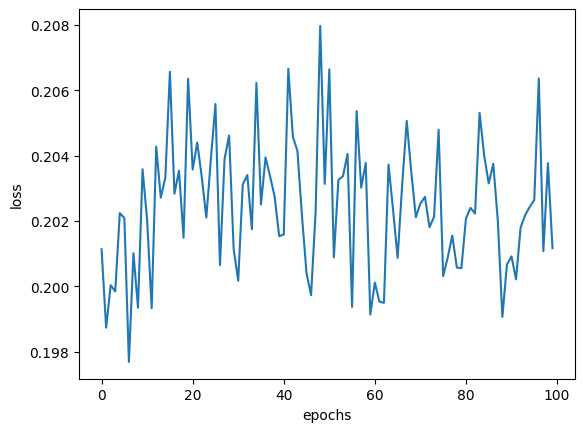

In [15]:
plt.plot(losses)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

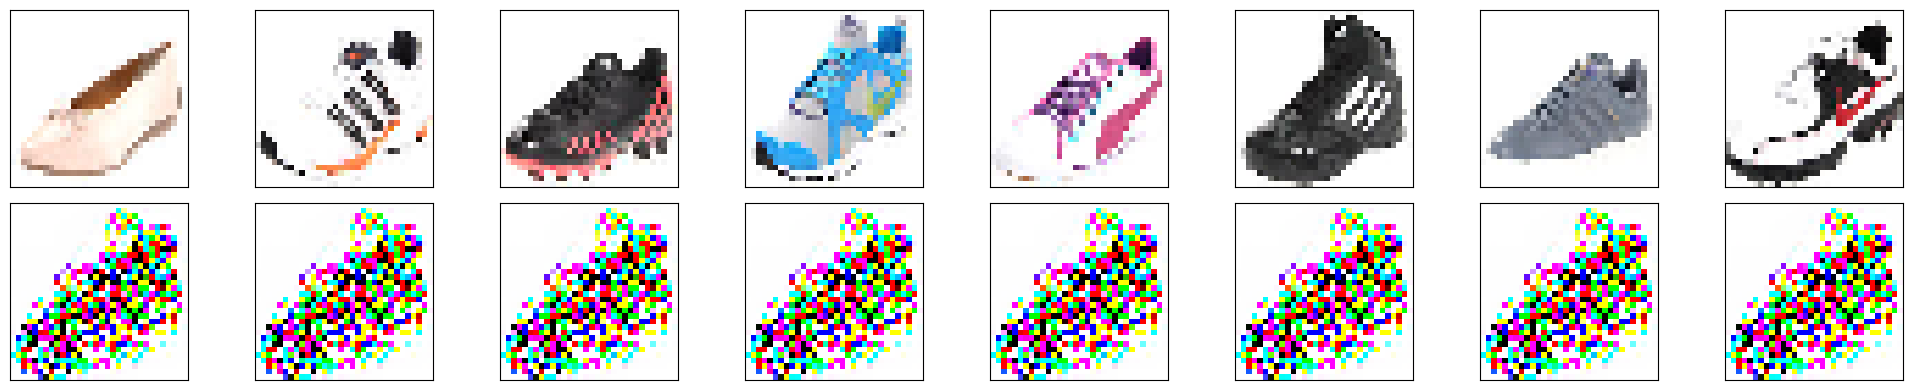

In [27]:
test = model.reconstruction(test_dataset)

row, col = 2, 8
f, axarr = plt.subplots(row, col, sharex =True, sharey=True, figsize = (20, 4))

idx = np.random.randint(0, 100, row*col // 2)

for fig, row in zip([test_dataset, test], axarr):
    for i, ax in zip(idx, row):
        ax.imshow(tf.reshape(fig[i], [IMAGE_SIZE, IMAGE_SIZE, 3]))
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()
        


